In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import pathlib
from sklearn import datasets, metrics
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.simplefilter('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
# Block 1

# Verify the GPU has been enabled
tf.test.gpu_device_name()

'/device:GPU:0'

In [3]:
# Block 2:

data=pd.read_csv('https://raw.githubusercontent.com/xialongtc10/MGT4250/main/20_News.csv', encoding='ISO-8859-1')  #Change the file name to your data
print("dimension of data: {}".format(data.shape))
data.head()

dimension of data: (11314, 3)


,id,message,topic
0,0,From: lerxst@wam.umd.edu (where's my thing)\r\...,7
1,1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4
2,2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4
3,3,From: jgreen@amber (Joe Green)\r\nSubject: Re:...,1
4,4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14


In [4]:
# Block 3

text_input = data["message"]   # Change the column name to be your text variable name
y = data["topic"]    # Change the column name to be your target variable

In [5]:
# Block 4: Builds and fits a text vectorizer, then extracts the vocabulary.

vectorizer = tf.keras.layers.TextVectorization(max_tokens=20000, output_sequence_length=200)
text_ds = tf.data.Dataset.from_tensor_slices(text_input).batch(128)
vectorizer.adapt(text_ds)
voc = vectorizer.get_vocabulary()
word_index = dict(zip(voc, range(len(voc))))

In [6]:
# Block 5: Converts raw text into numerical token sequences using the vectorizer.

text_input = vectorizer(np.array([[s] for s in text_input])).numpy()
text_input[0]

array([  14,    1, 9231,   34,  205,   27,   36,  254,    8,   16,   78,
          1,   30,   68,    4, 2587,  546, 1608,   29,  256,    9,   24,
       1171,   25,  133,   58,   39,   95, 8350,   54,   15,   16,  254,
          9,  619,    2,   72,  239,   11,   24,    5,    1, 2079,  254,
       1024,    3,   17,   14,    2, 1219, 5414,  754, 4879,   11,   24,
        299,    5,    1,    2, 3643,   60,  144,  423,    7, 1212,    2,
        780, 7209,   24, 1580,   14,    2,  721,    4,    2,  677,   16,
          8,   38,    9,   73,   25,  133,   35,    1,    5,  801,  258,
        979, 2454,  153,    4, 2546,  121,   16,  254,    8,  196,  558,
         23,  744,  358,   13,   20,   15,   16,    1,  328,  254,  145,
        154,  164, 2271, 1186,    3,   13,   31,   47, 6732,    1,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [7]:
# Block 6: Converts class labels into one-hot encoded vectors.

print(y[0])
y = tf.keras.utils.to_categorical(y)
print(y[0])

7
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
# Block 7

X_train, X_test, y_train, y_test = train_test_split(text_input, y, test_size = 0.3)
print (X_train.shape, X_test.shape)

(7919, 200) (3395, 200)


In [9]:
# Block 8: Downloads GloVe embeddings and loads pretrained word vectors into memory.

data_path = tf.keras.utils.get_file(
    "glove6b",
    "http://nlp.stanford.edu/data/glove.6B.zip",
    extract=True,)

path_to_glove_file = pathlib.Path(data_path).parent / "glove6b/glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))
for word, vector in embeddings_index.items():
  print (word, vector)
  break

862182613/862182613 ━━━━━━━━━━━━━━━━━━━━ 167s 0us/step
Found 400000 word vectors.
the [-0.038194 -0.24487   0.72812  -0.39961   0.083172  0.043953 -0.39141
  0.3344   -0.57545   0.087459  0.28787  -0.06731   0.30906  -0.26384
 -0.13231  -0.20757   0.33395  -0.33848  -0.31743  -0.48336   0.1464
 -0.37304   0.34577   0.052041  0.44946  -0.46971   0.02628  -0.54155
 -0.15518  -0.14107  -0.039722  0.28277   0.14393   0.23464  -0.31021
  0.086173  0.20397   0.52624   0.17164  -0.082378 -0.71787  -0.41531
  0.20335  -0.12763   0.41367   0.55187   0.57908  -0.33477  -0.36559
 -0.54857  -0.062892  0.26584   0.30205   0.99775  -0.80481  -3.0243
  0.01254  -0.36942   2.2167    0.72201  -0.24978   0.92136   0.034514
  0.46745   1.1079   -0.19358  -0.074575  0.23353  -0.052062 -0.22044
  0.057162 -0.15806  -0.30798  -0.41625   0.37972   0.15006  -0.53212
 -0.2055   -1.2526    0.071624  0.70565   0.49744  -0.42063   0.26148
 -1.538    -0.30223  -0.073438 -0.28312   0.37104  -0.25217   0.016215
 -0.

In [10]:
# Block 9: Builds an embedding matrix aligned with the tokenizer vocabulary.

num_tokens = len(voc) + 2
embedding_dim = 100    # Pay attention to this! We will adjust this value later
hits = 0
misses = 0

embedding_matrix = np.random.rand(num_tokens, embedding_dim)
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

Converted 17488 words (2512 misses)


In [11]:
# Block 10: Defines a CNN-based text classification model using pretrained embeddings.

embedding_layer = tf.keras.layers.Embedding(
    num_tokens,
    embedding_dim,
    embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
    trainable=True,
)

int_sequences_input = tf.keras.Input(shape=(None,), dtype="int64")
embedded_sequences = embedding_layer(int_sequences_input)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(embedded_sequences)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
preds = tf.keras.layers.Dense(20, activation="softmax")(x)   # You will need to adjust
model = tf.keras.Model(int_sequences_input, preds)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 100)      │     2,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 128)      │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,165,468 (8.26 MB)

 Trainable params: 2,165,468 (8.26 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Block 11: Compiles the model and trains it on the training data with early stopping.

callbacks = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)

model.compile(
    loss="categorical_crossentropy", optimizer="rmsprop", metrics=["acc"]
)
history1 = model.fit(X_train, y_train, batch_size=64, callbacks=[callbacks], epochs=50, validation_split=0.3)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - acc: 0.0862 - loss: 2.9302 - val_acc: 0.2180 - val_loss: 2.5320
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.2116 - loss: 2.3810 - val_acc: 0.3085 - val_loss: 2.0472
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.3608 - loss: 1.8777 - val_acc: 0.5391 - val_loss: 1.4802
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.4891 - loss: 1.4781 - val_acc: 0.5215 - val_loss: 1.3924
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.5990 - loss: 1.1812 - val_acc: 0.6031 - val_loss: 1.1469
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.6711 - loss: 0.9615 - val_acc: 0.6364 - val_loss: 1.0515
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.7409 - loss: 0.7862 - val_acc: 0.7184 - val_loss: 0.8536
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.7907 - loss: 0.6304 - val_acc: 0.7437 - val_loss: 0.8030
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.831

In [13]:
# Block 12

predicted = np.argmax(model.predict(X_test),axis=1)
expected = np.argmax(y_test,axis=1)

report = metrics.classification_report(expected,predicted)
print (report)

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.82      0.70      0.76       141
           1       0.72      0.70      0.71       180
           2       0.76      0.72      0.74       182
           3       0.77      0.45      0.57       177
           4       0.59      0.81      0.68       172
           5       0.82      0.68      0.74       186
           6       0.67      0.83      0.74       181
           7       0.85      0.68      0.75       172
           8       0.77      0.85      0.81       178
           9       0.87      0.96      0.91       169
          10       0.89      0.96      0.92       191
          11       0.93      0.90      0.92       175
          12       0.73      0.67      0.70       156
          13       0.90      0.91      0.90       190
          14       0.92      0.90      0.91       168
          15       0.83      0.86      0.85       176
          16       0.92      0.80      0

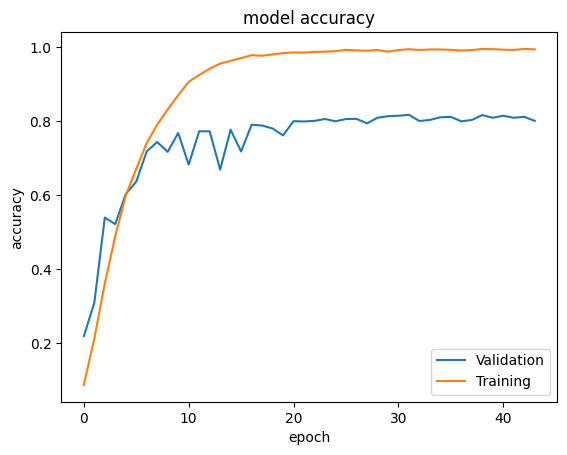

In [14]:
# Block 13: Plots training and validation accuracy across epochs.

from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy

plt.plot(history1.history['val_acc'])
plt.plot(history1.history['acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Validation', 'Training'], loc='lower right')
plt.show()

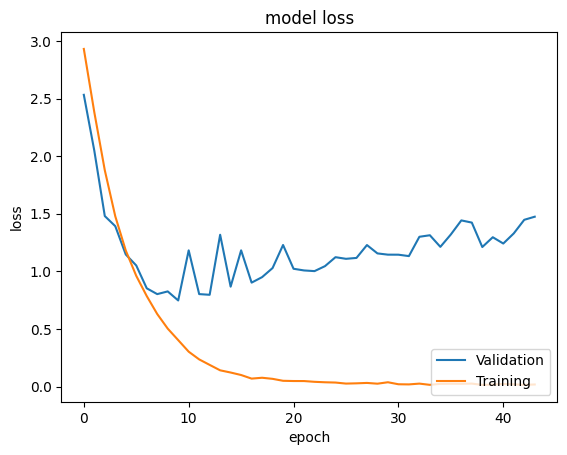

In [15]:
# Block 14: Plots training and validation loss across epochs.

plt.plot(history1.history['val_loss'])
plt.plot(history1.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Validation', 'Training'], loc='lower right')
plt.show()

# Now, let's try some other model architectures!

# Option 1: Different Convolutional Neural Network Architectures

In [16]:
# Block 15

int_sequences_input = tf.keras.Input(shape=(None,), dtype="int64")
embedded_sequences = embedding_layer(int_sequences_input)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(embedded_sequences)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.MaxPooling1D(5)(x)
x = tf.keras.layers.Conv1D(128, 5, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
preds = tf.keras.layers.Dense(20, activation="softmax")(x)
model = tf.keras.Model(int_sequences_input, preds)

In [17]:
# Block 16
callbacks = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)
model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["acc"]
)
history9 = model.fit(X_train, y_train, batch_size=64, callbacks=[callbacks], epochs=50, validation_split=0.3)

predicted = np.argmax(model.predict(X_test),axis=1)
expected = np.argmax(y_test,axis=1)
report = metrics.classification_report(expected,predicted)
print (report)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - acc: 0.0658 - loss: 3.0756 - val_acc: 0.0711 - val_loss: 2.9607
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.1068 - loss: 2.8147 - val_acc: 0.1928 - val_loss: 2.7208
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.1975 - loss: 2.3980 - val_acc: 0.4019 - val_loss: 2.4044
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.3439 - loss: 1.8818 - val_acc: 0.5164 - val_loss: 1.9334
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.5019 - loss: 1.4117 - val_acc: 0.6309 - val_loss: 1.5197
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.6087 - loss: 1.0952 - val_acc: 0.6814 - val_loss: 1.3238
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.6868 - loss: 0.8921 - val_acc: 0.7290 - val_loss: 1.1586
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7519 - loss: 0.7179 - val_acc: 0.7609 - val_loss: 0.9741
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7972 - loss

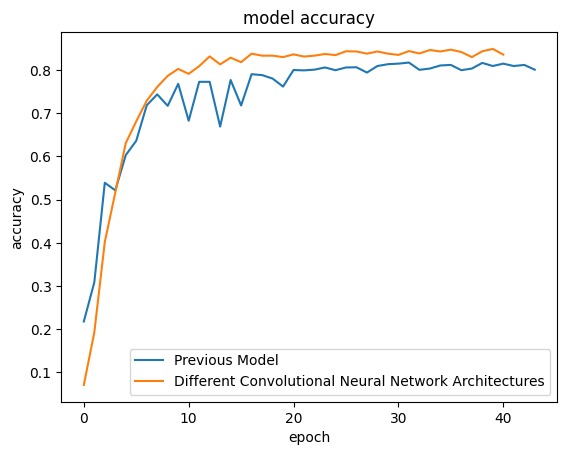

In [18]:
# Block 17

plt.plot(history1.history['val_acc'])
plt.plot(history9.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Previous Model', 'Different Convolutional Neural Network Architectures'], loc='lower right')
plt.show()

#Option 2: Recurrent Neural Network (LSTM)

In [25]:
# Block 18

model = tf.keras.models.Sequential()
model.add(embedding_layer)
#model.add(tf.keras.layers.LSTM(units=64, dropout=0.2, return_sequences=True))
#model.add(tf.keras.layers.LSTM(units=64, dropout=0.2))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=100, dropout=0.2)))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(20, activation='softmax'))

In [26]:
# Block 19
callbacks = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)
model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["acc"]
)
history10 = model.fit(X_train, y_train, batch_size=64, callbacks=[callbacks], epochs=50, validation_split=0.3)

predicted = np.argmax(model.predict(X_test),axis=1)
expected = np.argmax(y_test,axis=1)
report = metrics.classification_report(expected,predicted)
print (report)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - acc: 0.2318 - loss: 2.5125 - val_acc: 0.5295 - val_loss: 1.6010
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.6067 - loss: 1.2232 - val_acc: 0.7454 - val_loss: 0.8855
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.8192 - loss: 0.6098 - val_acc: 0.8157 - val_loss: 0.5979
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - acc: 0.9102 - loss: 0.3441 - val_acc: 0.8582 - val_loss: 0.4990
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.9610 - loss: 0.1746 - val_acc: 0.8552 - val_loss: 0.5323
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9684 - loss: 0.1389 - val_acc: 0.8725 - val_loss: 0.4713
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9861 - loss: 0.0738 - val_acc: 0.8678 - val_loss: 0.5238
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9903 - loss: 0.0523 - val_acc: 0.8704 - val_loss: 0.5287
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9904

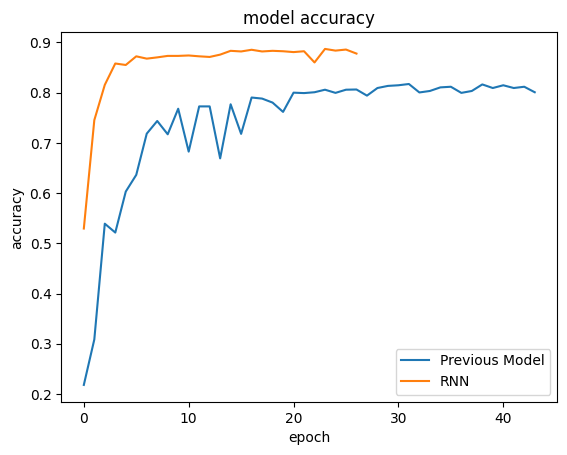

In [27]:
# Block 20

plt.plot(history1.history['val_acc'])
plt.plot(history10.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Previous Model', 'RNN'], loc='lower right')
plt.show()

# Option 3: Combining RNN and CNN

In [28]:
# Block 21

model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Conv1D(1024,5, activation='relu'))
model.add(tf.keras.layers.MaxPooling1D())
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=100, dropout=0.2)))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(20, activation='softmax'))

In [29]:
# Block 22
callbacks = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)
model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["acc"]
)
history11 = model.fit(X_train, y_train, batch_size=64, callbacks=[callbacks], epochs=50, validation_split=0.3)

predicted = np.argmax(model.predict(X_test),axis=1)
expected = np.argmax(y_test,axis=1)
report = metrics.classification_report(expected,predicted)
print (report)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - acc: 0.3108 - loss: 2.2855 - val_acc: 0.7513 - val_loss: 1.1808
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.8337 - loss: 0.6479 - val_acc: 0.8657 - val_loss: 0.4688
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.9536 - loss: 0.2143 - val_acc: 0.8763 - val_loss: 0.4424
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.9793 - loss: 0.1136 - val_acc: 0.8843 - val_loss: 0.4433
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.9794 - loss: 0.0926 - val_acc: 0.8868 - val_loss: 0.4500
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.9839 - loss: 0.0670 - val_acc: 0.8918 - val_loss: 0.4600
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.9874 - loss: 0.0537 - val_acc: 0.8746 - val_loss: 0.5078
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.9901 - loss: 0.0472 - val_acc: 0.8918 - val_loss: 0.4695
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.9872

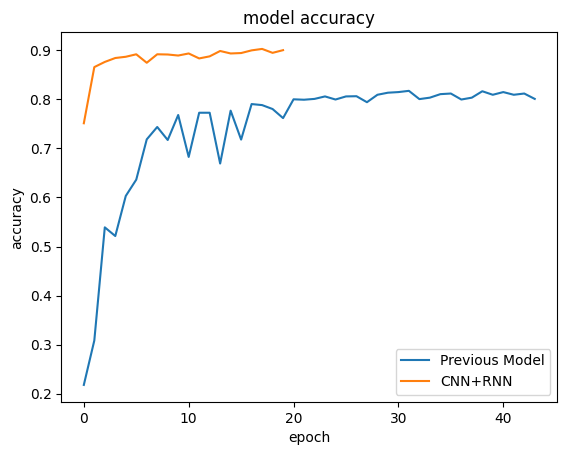

In [30]:
# Block 23

plt.plot(history1.history['val_acc'])
plt.plot(history11.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Previous Model', 'CNN+RNN'], loc='lower right')
plt.show()

# **Bonus**: Why writing deep learning codes from scratch is not required in this course?

*   Instead, **understanding the code, being able to reuse, and more importantly, knowing where to make improvements** are the key!
*   Search on ChatGPT: "**Write me a complete code with a CNN model for 20-news classification using Tensorflow in one block**"

In [31]:
# CNN for 20-Newsgroups text classification (TensorFlow / Keras)
# - Fetches 20-newsgroups (scikit-learn)
# - Splits train/val/test
# - Uses TextVectorization + Embedding + Conv1D + GlobalMaxPooling
# - Trains + evaluates + prints a classification report
#
# Run in Google Colab:
#   !pip -q install scikit-learn

import os
import random
import numpy as np
import tensorflow as tf

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------
# Load data (20 Newsgroups)
# -----------------------------
# remove headers/footers/quotes to reduce leakage and boilerplate
remove = ("headers", "footers", "quotes")
train_data = fetch_20newsgroups(subset="train", remove=remove)
test_data  = fetch_20newsgroups(subset="test",  remove=remove)

X_train_full = np.array(train_data.data, dtype=object)
y_train_full = np.array(train_data.target, dtype=np.int64)

X_test = np.array(test_data.data, dtype=object)
y_test = np.array(test_data.target, dtype=np.int64)

num_classes = int(np.max(y_train_full)) + 1
target_names = train_data.target_names

# Split train -> train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}  Classes: {num_classes}")

# -----------------------------
# Text vectorization
# -----------------------------
max_tokens = 40000     # vocabulary size
sequence_len = 400     # max length (tokens)
batch_size = 64

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_len,
    standardize="lower_and_strip_punctuation",
)

# Adapt on training text only
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(256))

def make_ds(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(texts), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_raw = make_ds(X_train, y_train, shuffle=True)
val_ds_raw   = make_ds(X_val, y_val, shuffle=False)
test_ds_raw  = make_ds(X_test, y_test, shuffle=False)

# -----------------------------
# Model: CNN (Conv1D)
# -----------------------------
embedding_dim = 128
dropout = 0.3

inputs = tf.keras.Input(shape=(), dtype=tf.string, name="text")
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(input_dim=max_tokens, output_dim=embedding_dim, name="emb")(x)

# Multi-kernel CNN block (common for text CNNs)
conv3 = tf.keras.layers.Conv1D(128, 3, padding="same", activation="relu")(x)
conv4 = tf.keras.layers.Conv1D(128, 4, padding="same", activation="relu")(x)
conv5 = tf.keras.layers.Conv1D(128, 5, padding="same", activation="relu")(x)

pool3 = tf.keras.layers.GlobalMaxPooling1D()(conv3)
pool4 = tf.keras.layers.GlobalMaxPooling1D()(conv4)
pool5 = tf.keras.layers.GlobalMaxPooling1D()(conv5)

x = tf.keras.layers.Concatenate()([pool3, pool4, pool5])
x = tf.keras.layers.Dropout(dropout)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(dropout)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

# -----------------------------
# Train
# -----------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

history = model.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=15,
    callbacks=callbacks,
    verbose=1,
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(val_ds_raw, verbose=0)
test_loss, test_acc = model.evaluate(test_ds_raw, verbose=0)
print(f"\nVal accuracy:  {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# -----------------------------
# Predictions + report
# -----------------------------
# Collect predictions on test set
y_pred_probs = model.predict(test_ds_raw, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred, target_names=target_names, digits=2))

# -----------------------------
# Example inference
# -----------------------------
examples = [
    "The GPU drivers on Linux are causing kernel panics after the update.",
    "I’m looking to buy a used motorcycle helmet and need recommendations.",
    "The space shuttle program was an incredible engineering achievement.",
]
pred = model.predict(tf.constant(examples), verbose=0)
pred_ids = np.argmax(pred, axis=1)
for t, cid in zip(examples, pred_ids):
    print(f"\nText: {t}\nPredicted class: {target_names[cid]}")


Train: 9616  Val: 1698  Test: 7532  Classes: 20


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 400)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb (Embedding)     │ (None, 400, 128)  │  5,120,000 │ text_vectorizati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 400, 128)  │     49,280 │ emb[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 400, 128)  │     65,664 │ emb[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 400, 128)  │     82,048 │ emb[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_6[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_7[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     98,560 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256)       │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 20)        │      5,140 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,420,692 (20.68 MB)

 Trainable params: 5,420,692 (20.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.1858 - loss: 2.6598 - val_accuracy: 0.4800 - val_loss: 1.7192 - learning_rate: 0.0020
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5856 - loss: 1.3518 - val_accuracy: 0.6502 - val_loss: 1.1758 - learning_rate: 0.0020
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7853 - loss: 0.7076 - val_accuracy: 0.6773 - val_loss: 1.1299 - learning_rate: 0.0020
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8958 - loss: 0.3547 - val_accuracy: 0.6761 - val_loss: 1.2635 - learning_rate: 0.0020
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9357 - loss: 0.2285 - val_accuracy: 0.6832 - val_loss: 1.3464 - learning_rate: 0.0020
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9621 - loss: 0.1413 - val_accuracy: 0.6967 - val_loss: 1.4174 - learning_rate: 0.0010
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9661 - loss: 0.